# Data Exploration
We are looking at the steam games datasets. 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100


In [2]:
train = pd.read_csv("data/train.csv")
items= pd.read_csv("data/item_metadata.csv")
test_users= pd.read_csv("data/test_users.csv")

In [ ]:
train.shape # 122,366 total user-item interactions

(122366, 4)

In [ ]:
items.shape # metadata dataset

(32132, 9)

In [ ]:
test_users.shape # 10,000 test users 

(10000, 1)

Goal Statement: predict top-10 next games for each of 10,000 test users, info we have is 32,132 games and metadata as well as 122,366 user-otem interactions to understand what the users like.

# Start the EDA! 
Lets start with taking a look at the dataframes we have and the columns 

In [ ]:
train.head(10) # in the interactions we are given the playtime minutes and timestamp,  which is the unix timestamp of the review

,user_id,item_id,playtime_minutes,timestamp
0,u_00000,i_20975,168,1427612400
1,u_00000,i_08250,660,1427612400
2,u_00000,i_01923,606,1430809200
3,u_00000,i_27675,258,1456300800
4,u_00000,i_06792,54,1461481200
5,u_00000,i_22342,540,1461481200
6,u_00001,i_10930,2064,1482912000
7,u_00001,i_18188,270,1493276400
8,u_00001,i_00428,288,1493276400
9,u_00001,i_23257,6,1493276400


In [17]:
interaction_counts = pd.DataFrame(train.groupby('user_id').size().rename('interaction_counts'))

In [19]:
interaction_counts

,interaction_counts
user_id,
u_00000,6
u_00001,7
u_00002,5
u_00003,14
u_00004,3
...,...
u_09995,5
u_09996,28
u_09997,3


In [18]:
interaction_counts.describe()

,interaction_counts
count,10000.000000
mean,12.236600
std,18.503185
min,3.000000
25%,4.000000
50%,7.000000
75%,13.000000
max,536.000000


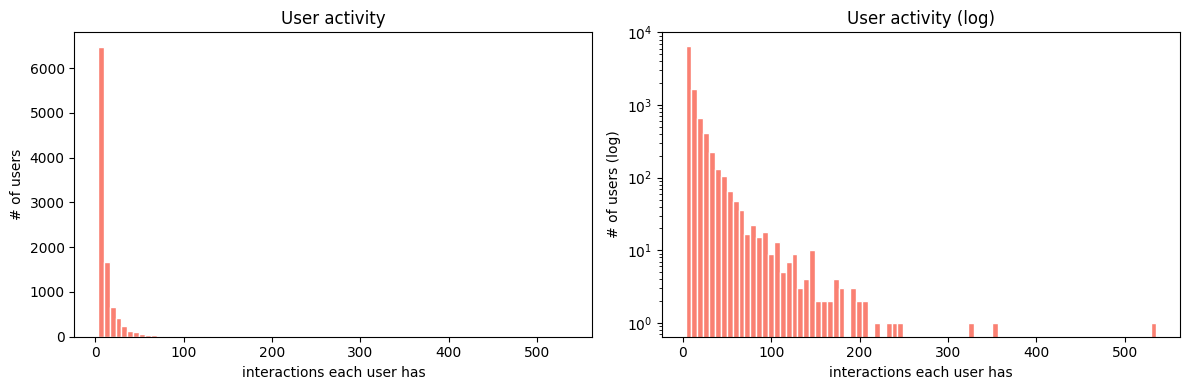

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(interaction_counts, bins=80, color="salmon", edgecolor="white")
axes[0].set_xlabel("interactions each user has")
axes[0].set_ylabel("# of users")
axes[0].set_title("User activity")

axes[1].hist(interaction_counts, bins=80, color="salmon", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xlabel("interactions each user has")
axes[1].set_ylabel("# of users (log)")
axes[1].set_title("User activity (log)")

plt.tight_layout()
plt.show()

In [26]:
train[train['playtime_minutes'] <= 0].count() # this is the count of reviews given with 0 playtime

user_id             677
item_id             677
playtime_minutes    677
timestamp           677
dtype: int64

# Item Popularity  


In [33]:
item_counts = pd.DataFrame(train.groupby("item_id").size().rename('item_count')) # how many times does each item show up in the dataset


In [34]:
item_counts

,item_count
item_id,
i_00000,2
i_00002,1
i_00003,32
i_00004,1
i_00005,2
...,...
i_32120,1
i_32127,14
i_32128,1


In [35]:
item_counts.describe()

,item_count
count,8036.000000
mean,15.227227
std,39.782772
min,1.000000
25%,1.000000
50%,4.000000
75%,11.000000
max,941.000000


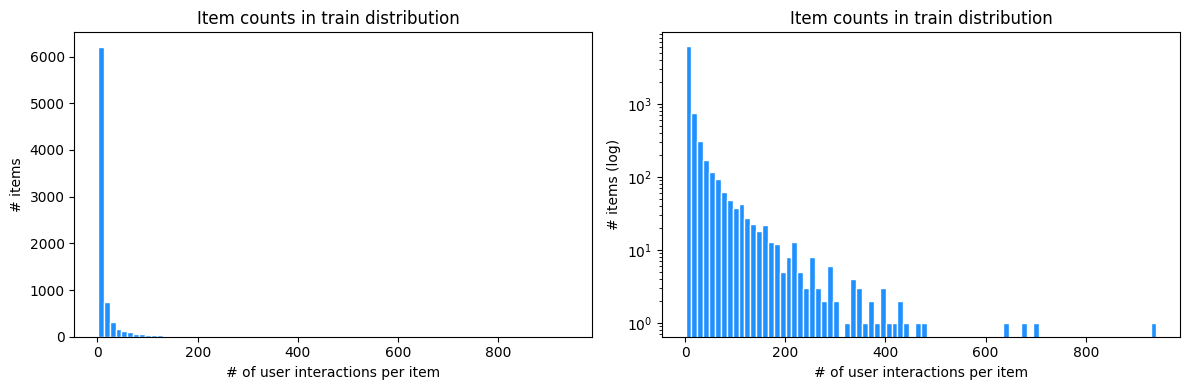

In [39]:
### Plot it!
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(item_counts, bins=80, color="dodgerblue", edgecolor="white")
axes[0].set_xlabel("# of user interactions per item"); axes[0].set_ylabel("# items")
axes[0].set_title("Item counts in train distribution  ")

axes[1].hist(item_counts, bins=80, color="dodgerblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xlabel("# of user interactions per item"); axes[1].set_ylabel("# items (log)")
axes[1].set_title("Item counts in train distribution")
plt.tight_layout(); plt.show()

### Lets now look at the Playtime Distribution 
The data card has warned that the playtime values have an odd skew and we should be applying log1p or else the long tail will dominate our results.

In [43]:
playtime_iso = train['playtime_minutes']
playtime_iso.describe() # we already know that there are 677 rows with a playtime of 0

count    1.223660e+05
mean     3.080861e+03
std      1.350057e+04
min      0.000000e+00
25%      1.500000e+02
50%      5.160000e+02
75%      1.668000e+03
max      1.007958e+06
Name: playtime_minutes, dtype: float64

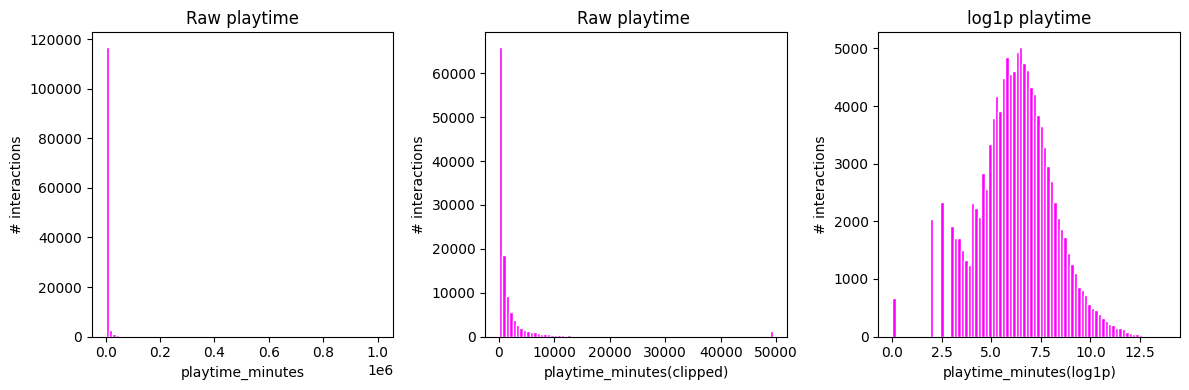

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(playtime_iso, bins=80, color="magenta", edgecolor="white") 
axes[0].set_xlabel("playtime_minutes")
axes[0].set_ylabel("# interactions")
axes[0].set_title("Raw playtime")
axes[2].hist(np.log1p(playtime_iso), bins=80, color="magenta", edgecolor="white") 
axes[2].set_xlabel("playtime_minutes(log1p)")
axes[2].set_ylabel("# interactions")
axes[2].set_title("log1p playtime")
axes[1].hist(playtime_iso.clip(upper = playtime_iso.quantile(0.99)), bins=80, color="magenta", edgecolor="white")
axes[1].set_xlabel("playtime_minutes(clipped)")
axes[1].set_ylabel("# interactions")
axes[1].set_title("Raw playtime ")

plt.tight_layout(); plt.show()

### Lets also take a Temporal Analysis

In [66]:
train['datetime_convert'] = pd.to_datetime(train['timestamp'], unit = 's')

In [67]:
train

,user_id,item_id,playtime_minutes,timestamp,datetime_convert
0,u_00000,i_20975,168,1427612400,2015-03-29 07:00:00
1,u_00000,i_08250,660,1427612400,2015-03-29 07:00:00
2,u_00000,i_01923,606,1430809200,2015-05-05 07:00:00
3,u_00000,i_27675,258,1456300800,2016-02-24 08:00:00
4,u_00000,i_06792,54,1461481200,2016-04-24 07:00:00
...,...,...,...,...,...
122361,u_09999,i_08645,0,1460358000,2016-04-11 07:00:00
122362,u_09999,i_04220,444,1462345200,2016-05-04 07:00:00
122363,u_09999,i_07062,30,1465974000,2016-06-15 07:00:00
122364,u_09999,i_01739,288,1473490800,2016-09-10 07:00:00


In [69]:
print(f"Timestamp range: {train['datetime_convert'].min()} to {train['datetime_convert'].max()}")


Timestamp range: 2010-10-16 07:00:00 to 2018-01-05 08:00:00


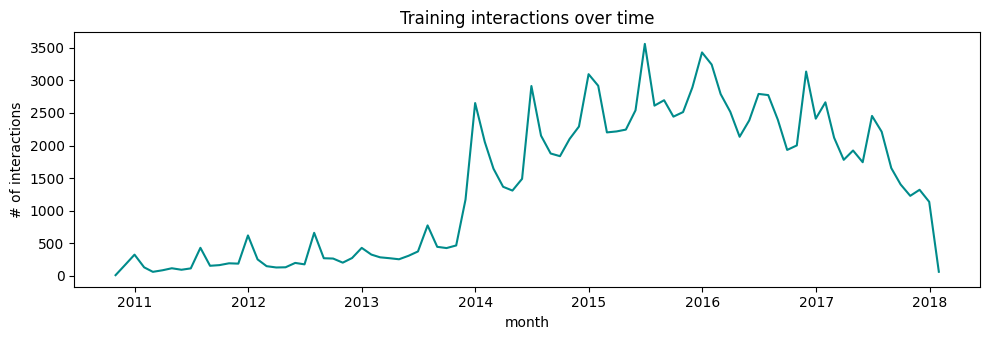

In [75]:
monthly = train.set_index("datetime_convert").resample("ME").size() # resampling for month-end frequency, group data by month and then apply aggregation functions
# then we apply .size() to the resampled object to count the number of observation in each month bin
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(monthly.index, monthly.values, color="darkcyan")
ax.set_xlabel("month"); ax.set_ylabel("# of interactions")
ax.set_title("Training interactions over time")
plt.tight_layout(); plt.show()

# Lets now look at the item data

In [110]:
items

,item_id,title,tags,genres,specs,developer,publisher,release_year,sentiment,tags_list,genres_list,specs_list
0,i_00000,Counter-Strike,Action|FPS|Multiplayer|Shooter|Classic|Team-Ba...,Action,Multi-player|Valve Anti-Cheat enabled,Valve,Valve,2000,Overwhelmingly Positive,"[Action, FPS, Multiplayer, Shooter, Classic, T...",[Action],"[Multi-player, Valve Anti-Cheat enabled]"
1,i_00001,Rag Doll Kung Fu,Indie|Fighting|Multiplayer,Indie,Single-player|Multi-player,Mark Healey,Mark Healey,2005,Mixed,"[Indie, Fighting, Multiplayer]",[Indie],"[Single-player, Multi-player]"
2,i_00002,Silo 2,Animation & Modeling|Software,Animation &amp; Modeling,NaN,Nevercenter Ltd. Co.,Nevercenter Ltd. Co.,2012,Mostly Positive,"[Animation & Modeling, Software]",[Animation &amp; Modeling],[]
3,i_00003,Call of Duty: World at War,Zombies|World War II|FPS|Action|Multiplayer|Sh...,Action,Single-player|Multi-player|Co-op,Treyarch,Activision,2008,Very Positive,"[Zombies, World War II, FPS, Action, Multiplay...",[Action],"[Single-player, Multi-player, Co-op]"
4,i_00004,3D-Coat V4.8,Animation & Modeling,Animation &amp; Modeling,Steam Cloud,Pilgway,Pilgway,2012,Very Positive,[Animation & Modeling],[Animation &amp; Modeling],[Steam Cloud]
...,...,...,...,...,...,...,...,...,...,...,...,...
32127,i_32127,NightSky,Indie|Platformer|Casual|Puzzle|Physics|Atmosph...,Casual|Indie|Strategy,Single-player,"Nicalis, Inc.","Nicalis, Inc.",2011,Very Positive,"[Indie, Platformer, Casual, Puzzle, Physics, A...","[Casual, Indie, Strategy]",[Single-player]
32128,i_32128,The UnderGarden,Casual|Puzzle|Relaxing|Exploration,Casual,Single-player,Artech Studios,Retroism,2010,Mixed,"[Casual, Puzzle, Relaxing, Exploration]",[Casual],[Single-player]
32129,i_32129,Spiral Knights,Free to Play|Massively Multiplayer|Adventure|R...,Action|Adventure|Free to Play|Indie|Massively ...,Single-player|Multi-player|MMO|Co-op|Steam Ach...,Grey Havens,NaN,2011,Very Positive,"[Free to Play, Massively Multiplayer, Adventur...","[Action, Adventure, Free to Play, Indie, Massi...","[Single-player, Multi-player, MMO, Co-op, Stea..."
32130,i_32130,Puzzle Pirates,Free to Play|Massively Multiplayer|Puzzle|Casu...,Adventure|Casual|Free to Play|Massively Multip...,Single-player|Multi-player|MMO|Co-op|Steam Ach...,Three Rings,Three Rings,2011,Very Positive,"[Free to Play, Massively Multiplayer, Puzzle, ...","[Adventure, Casual, Free to Play, Massively Mu...","[Single-player, Multi-player, MMO, Co-op, Stea..."


# Deep dive on the items metadata

In [111]:
# it is mentioned in th GOtchas section that the tags are very imbalances so I want to look at that part specifcically 
# Each tag is split by a pipe operator so we can write a functaion to seperate them use apply to split pipe operators on tags, genres and specs columns
def split_pipe(s):
    if pd.isna(s) or s == "":
        return []
    return [t.strip() for t in s.split("|") if t.strip()]

In [112]:
items["tags_list"]   = items["tags"].apply(split_pipe)
items["genres_list"] = items["genres"].apply(split_pipe)
items["specs_list"]  = items["specs"].apply(split_pipe)

In [113]:
#  create a counter obect to loop through each observations tag list, and add tags in current list to counter
# we can get unique count of each tag this way and display it
tag_counter = Counter()
for tag_list in items["tags_list"]:
    tag_counter.update(tag_list)

In [114]:
len(tag_counter) # 339 distinct tags to describe the games?

339

In [115]:
print(f"Mean tags per item: {round(items['tags_list'].apply(len).mean())}") # on everage each item has around 5~ tags

Mean tags per item: 5


In [116]:
popular_tags = pd.DataFrame(tag_counter.most_common(25), columns =["tag", "item_count"])

In [117]:
popular_tags["catalog_coverage"] = (popular_tags["item_count"] / len(items)).map("{:.1%}".format)


In [118]:
popular_tags

,tag,item_count,catalog_coverage
0,Indie,17620,54.8%
1,Action,13003,40.5%
2,Adventure,9829,30.6%
3,Casual,9739,30.3%
4,Simulation,7730,24.1%
5,Strategy,7566,23.5%
6,RPG,5919,18.4%
7,Singleplayer,4344,13.5%
8,Free to Play,2406,7.5%
9,Multiplayer,2383,7.4%


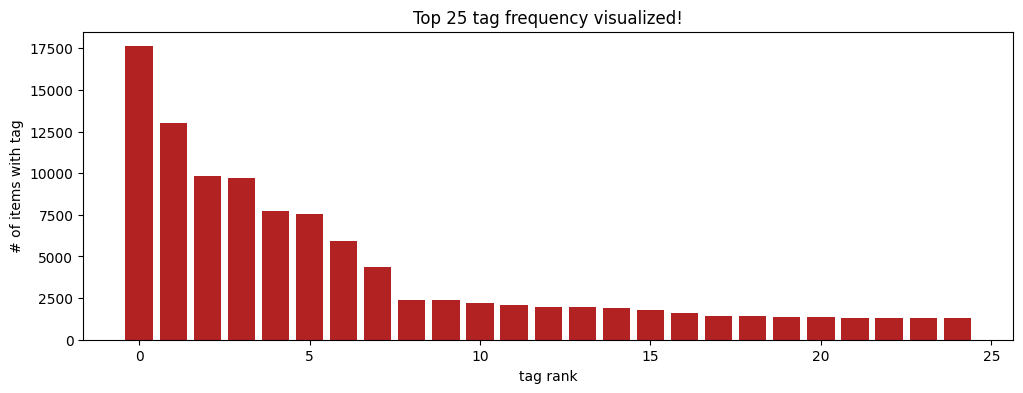

In [119]:
tag_frequency = np.array(sorted(tag_counter.values(), reverse=True))
plt.figure(figsize=(12, 4))
plt.bar(range(25), tag_frequency[:25], color="firebrick")
plt.xlabel("tag rank")
plt.ylabel("# of items with tag")
plt.title("Top 25 tag frequency visualized!")
plt.show()

#### Lets look at the genres in the same fashion!

In [140]:
genre_counter = Counter()
for genre_list in items["genres_list"]:
    genre_counter.update(genre_list)


In [141]:
len(genre_counter)


22

In [142]:
print(f"Mean genres per item: {round(items['genres_list'].apply(len).mean())}") # on average each item has around 2~ genres

Mean genres per item: 2


In [148]:
popular_genres = pd.DataFrame(genre_counter.most_common(), columns =["genres", "item_count"])

In [149]:
popular_genres["catalog_coverage"] = (popular_genres["item_count"] / len(items)).map("{:.1%}".format)


In [150]:
popular_genres

,genres,item_count,catalog_coverage
0,Indie,15858,49.4%
1,Action,11319,35.2%
2,Casual,8282,25.8%
3,Adventure,8242,25.7%
4,Strategy,6957,21.7%
5,Simulation,6699,20.8%
6,RPG,5479,17.1%
7,Free to Play,2031,6.3%
8,Early Access,1462,4.5%
9,Sports,1257,3.9%


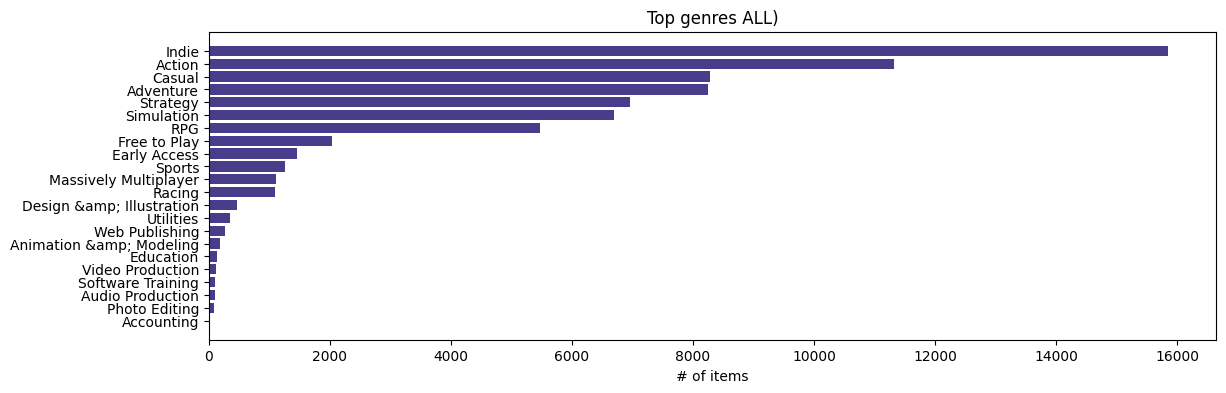

In [154]:
plt.figure(figsize=(13, 4))
g_top = pd.Series(dict(genre_counter.most_common(22)))
plt.barh(g_top.index[::-1], g_top.values[::-1], color="darkslateblue")
plt.title(f"Top genres ALL)")
plt.xlabel("# of items")
plt.show()

#### Lastly lets look at specs

In [155]:
specs_counter = Counter()
for spec_list in items["specs_list"]:
    specs_counter.update(spec_list)

In [156]:
len(specs_counter)

40

In [158]:
print(f"Mean specs per item: {round(items['specs_list'].apply(len).mean())}") # on average each item has around 4 specs

Mean specs per item: 4


In [159]:
popular_specs = pd.DataFrame(specs_counter.most_common(), columns =["specs", "item_count"])

In [161]:
popular_specs["catalog_coverage"] = (popular_specs["item_count"] / len(items)).map("{:.1%}".format)

In [163]:
popular_specs

,specs,item_count,catalog_coverage
0,Single-player,27575,85.8%
1,Steam Achievements,16364,50.9%
2,Downloadable Content,12691,39.5%
3,Steam Trading Cards,12198,38.0%
4,Steam Cloud,9958,31.0%
5,Multi-player,8198,25.5%
6,Full controller support,7384,23.0%
7,Partial Controller Support,6538,20.3%
8,Steam Leaderboards,6081,18.9%
9,Co-op,4280,13.3%


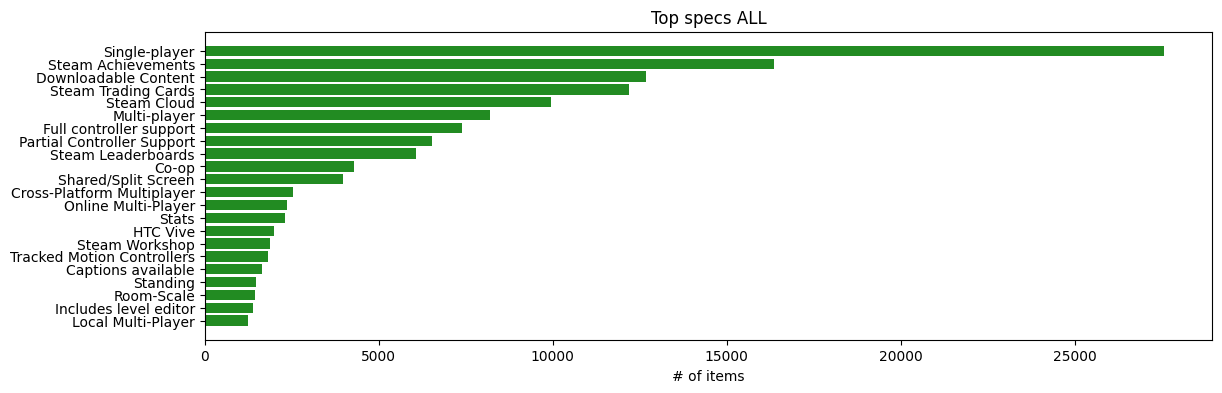

In [165]:
plt.figure(figsize=(13, 4))
specs_top = pd.Series(dict(specs_counter.most_common(22)))
plt.barh(specs_top.index[::-1], specs_top.values[::-1], color='forestgreen')
plt.title(f"Top specs ALL")
plt.xlabel("# of items")
plt.show()

## Lets look at the release year distribution

In [ ]:
items[items['release_year'] == -1].shape # 2216 observations with no year attached

(2216, 12)

In [172]:
year = items["release_year"]
year_valid = year[year != -1]

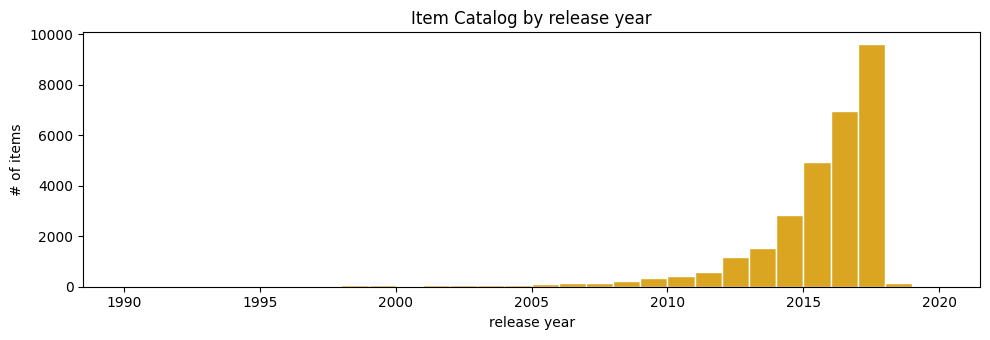

In [177]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(year_valid, bins=range(int(year_valid.min()), int(year_valid.max())), color="goldenrod", edgecolor="white")
ax.set_xlabel("release year")
ax.set_ylabel("# of items")
ax.set_title("Item Catalog by release year")
plt.tight_layout()
plt.show()

## Lets look at the Sentiments 
This will help us get an idea of the coverage

In [ ]:
items['sentiment'].unique() # interesting that when there is a lack of reviews it is replaced with the amount of user reviews given 

array(['Overwhelmingly Positive', 'Mixed', 'Mostly Positive',
       'Very Positive', 'Mostly Negative', '7 user reviews', 'Positive',
       nan, '9 user reviews', '4 user reviews', '3 user reviews',
       '1 user reviews', '5 user reviews', 'Very Negative', 'Negative',
       '2 user reviews', '8 user reviews', '6 user reviews',
       'Overwhelmingly Negative'], dtype=object)

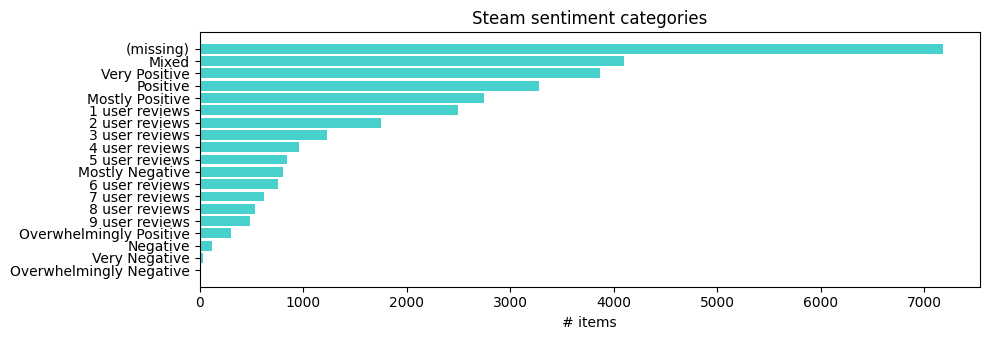

In [183]:
sent_counts = items["sentiment"].fillna("(missing)").value_counts()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(sent_counts.index[::-1], sent_counts.values[::-1], color="mediumturquoise")
ax.set_xlabel("# items"); ax.set_title("Steam sentiment categories")
plt.tight_layout(); plt.show()


In [ ]:
sent_counts # most of it is missing but we have some info

sentiment
(missing)                  7181
Mixed                      4103
Very Positive              3868
Positive                   3281
Mostly Positive            2743
1 user reviews             2496
2 user reviews             1756
3 user reviews             1231
4 user reviews              964
5 user reviews              846
Mostly Negative             802
6 user reviews              756
7 user reviews              619
8 user reviews              537
9 user reviews              488
Overwhelmingly Positive     302
Negative                    123
Very Negative                29
Overwhelmingly Negative       7
Name: count, dtype: int64

# Lets look at the Developers and Publishers

In [185]:
developer_count = items["developer"].value_counts()
publisher_count = items["publisher"].value_counts()

In [ ]:
len(developer_count) # 10,998 unique devs

10988

In [190]:
len(publisher_count) # 8233 unique publishers

8233

In [192]:
publisher_count.head(10).rename_axis("publisher").reset_index(name="title_count")

,publisher,title_count
0,Ubisoft,385
1,Dovetail Games - Trains,360
2,Degica,286
3,Paradox Interactive,271
4,SEGA,251
5,Dovetail Games - Flight,220
6,"KOEI TECMO GAMES CO., LTD.",208
7,Activision,202
8,Big Fish Games,195
9,KISS ltd,189


In [193]:
developer_count.head(10).rename_axis("developer").reset_index(name="title_count")

,developer,title_count
0,Ubisoft - San Francisco,1259
1,"SmiteWorks USA, LLC",813
2,Dovetail Games,253
3,"KOEI TECMO GAMES CO., LTD.",232
4,Paradox Development Studio,156
5,Capcom,130
6,Ronimo Games,123
7,Choice of Games,100
8,Musopia,95
9,Stainless Games,95


In [196]:
nUsers = train["user_id"].nunique()
nItem_Train = train["item_id"].nunique()
lenTrain = len(train)
totalCells = nUsers * nItem_Train
density = lenTrain / totalCells
nItem_ItemData = items["item_id"].nunique()


print(f"Users : {nUsers:,}")
print(f"Items (in train): {nItem_Train:,}")
print(f"Observations : {lenTrain:,}")
print(f"Possible cells : {totalCells:,}")
print(f"Density : {density:.5%}")
print(f"Sparsity : {1-density:.5%}")

Users : 10,000
Items (in train): 8,036
Observations : 122,366
Possible cells : 80,360,000
Density : 0.15227%
Sparsity : 99.84773%


### Lets also look at cold items
Cold Items are items with no training interactions.

In [197]:
train_items = set(train["item_id"].unique())

In [199]:
len(train_items)

8036

In [ ]:
items["is_cold"] = ~items["item_id"].isin(train_items) # boolean mask what items in the metadata have no interaction history


In [203]:
items

,item_id,title,tags,genres,specs,developer,publisher,release_year,sentiment,tags_list,genres_list,specs_list,is_cold
0,i_00000,Counter-Strike,Action|FPS|Multiplayer|Shooter|Classic|Team-Ba...,Action,Multi-player|Valve Anti-Cheat enabled,Valve,Valve,2000,Overwhelmingly Positive,"[Action, FPS, Multiplayer, Shooter, Classic, T...",[Action],"[Multi-player, Valve Anti-Cheat enabled]",False
1,i_00001,Rag Doll Kung Fu,Indie|Fighting|Multiplayer,Indie,Single-player|Multi-player,Mark Healey,Mark Healey,2005,Mixed,"[Indie, Fighting, Multiplayer]",[Indie],"[Single-player, Multi-player]",True
2,i_00002,Silo 2,Animation & Modeling|Software,Animation &amp; Modeling,NaN,Nevercenter Ltd. Co.,Nevercenter Ltd. Co.,2012,Mostly Positive,"[Animation & Modeling, Software]",[Animation &amp; Modeling],[],False
3,i_00003,Call of Duty: World at War,Zombies|World War II|FPS|Action|Multiplayer|Sh...,Action,Single-player|Multi-player|Co-op,Treyarch,Activision,2008,Very Positive,"[Zombies, World War II, FPS, Action, Multiplay...",[Action],"[Single-player, Multi-player, Co-op]",False
4,i_00004,3D-Coat V4.8,Animation & Modeling,Animation &amp; Modeling,Steam Cloud,Pilgway,Pilgway,2012,Very Positive,[Animation & Modeling],[Animation &amp; Modeling],[Steam Cloud],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32127,i_32127,NightSky,Indie|Platformer|Casual|Puzzle|Physics|Atmosph...,Casual|Indie|Strategy,Single-player,"Nicalis, Inc.","Nicalis, Inc.",2011,Very Positive,"[Indie, Platformer, Casual, Puzzle, Physics, A...","[Casual, Indie, Strategy]",[Single-player],False
32128,i_32128,The UnderGarden,Casual|Puzzle|Relaxing|Exploration,Casual,Single-player,Artech Studios,Retroism,2010,Mixed,"[Casual, Puzzle, Relaxing, Exploration]",[Casual],[Single-player],False
32129,i_32129,Spiral Knights,Free to Play|Massively Multiplayer|Adventure|R...,Action|Adventure|Free to Play|Indie|Massively ...,Single-player|Multi-player|MMO|Co-op|Steam Ach...,Grey Havens,NaN,2011,Very Positive,"[Free to Play, Massively Multiplayer, Adventur...","[Action, Adventure, Free to Play, Indie, Massi...","[Single-player, Multi-player, MMO, Co-op, Stea...",False
32130,i_32130,Puzzle Pirates,Free to Play|Massively Multiplayer|Puzzle|Casu...,Adventure|Casual|Free to Play|Massively Multip...,Single-player|Multi-player|MMO|Co-op|Steam Ach...,Three Rings,Three Rings,2011,Very Positive,"[Free to Play, Massively Multiplayer, Puzzle, ...","[Adventure, Casual, Free to Play, Massively Mu...","[Single-player, Multi-player, MMO, Co-op, Stea...",False


In [205]:
print(f"Cold items: {items['is_cold'].sum()} / {len(items)} ({items['is_cold'].mean():.1%})")


Cold items: 24096 / 32132 (75.0%)


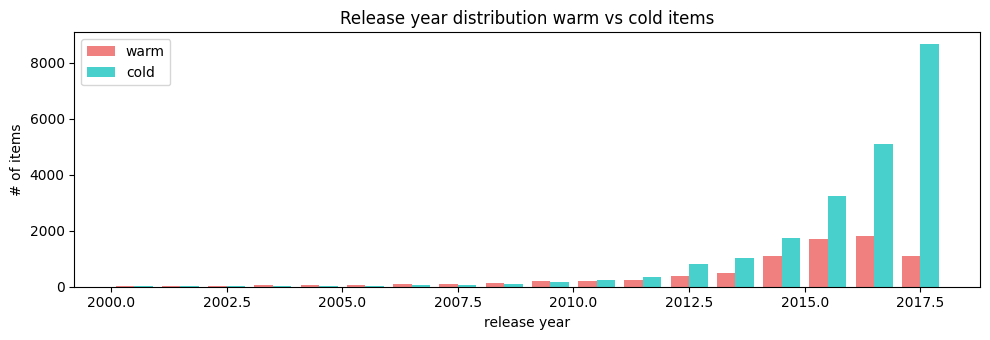

In [208]:
#  release-year distribution cold versus warm
fig, ax = plt.subplots(figsize=(10, 3.5))
warm_yrs = items.loc[~items["is_cold"] & (items["release_year"]!= -1), "release_year"]
cold_yrs = items.loc[ items["is_cold"] & (items["release_year"]!= -1), "release_year"]
bins = range(2000, 2019)
ax.hist([warm_yrs, cold_yrs], bins=bins, label=["warm", "cold"], color=["lightcoral", "mediumturquoise"])
ax.set_xlabel("release year")
ax.set_ylabel("# of items")
ax.set_title("Release year distribution warm vs cold items")
ax.legend()
plt.tight_layout()
plt.show()